In [276]:
import pandas as pd
import os
import sys
import json
from pathlib import Path
import numpy as np

# Notebook is in notebooks/, so repo root is parent
REPO_ROOT = Path.cwd().parent
SRC_PATH = REPO_ROOT / "src"

# Insert src at the front of sys.path so imports work
sys.path.insert(0, str(SRC_PATH))

In [277]:
# Get repo root relative to the current notebook
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Load static preprocessing config
config_path = os.path.join(repo_root, "configs", "xgboost_baseline_params.json")
with open(config_path, "r") as f:
    config = json.load(f)

# Set input and output directories
in_dir = os.path.join(repo_root, config["paths"]["in_dir"])

In [278]:
ed_vitals = pd.read_csv(os.path.join(in_dir, config["sources"]["vitals"]))
ed_vitals.head(5)

,subject_id,stay_id,charttime,temperature,heartrate,resprate,o2sat,sbp,dbp
0,17195991,38649090,2110-01-11 21:45:00,NaN,141.0,24.0,94.0,NaN,NaN
1,17195991,38649090,2110-01-11 21:50:00,NaN,123.0,24.0,91.0,151.0,120.0
2,17195991,38649090,2110-01-11 22:00:00,NaN,133.0,23.0,99.0,180.0,86.0
3,17195991,38649090,2110-01-11 22:07:00,NaN,164.0,24.0,99.0,198.0,116.0
4,17195991,38649090,2110-01-11 22:23:00,NaN,130.0,16.0,100.0,235.0,126.0


In [279]:
clinical_encounters = pd.read_csv(os.path.join(in_dir, config["sources"]["clinical_encounters"]), dtype=str, low_memory=False)
print(clinical_encounters.shape)
clinical_encounters.head(5)

(494231, 86)


,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,...,label_stemi,label_subsequent_mi,label_supraventricular_tachycardia,label_tia,label_unspecified_cardiac,label_unstable_angina,label_valvular_heart_disease,label_ventricular_arrhythmias,is_cardiovascular,is_specified_cardiac
0,10049341,20677333.0,34255415.0,2171-04-07 17:48:00,2171-04-08 09:31:00,2171-04-08 00:26:00,2171-04-08 09:31:00,ASIAN,F,55.0,...,0,0,0,0,0,0,0,0,0,0
1,10049341,NaN,35767475.0,2170-08-29 18:20:00,2170-08-29 22:46:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
2,10049341,NaN,36382949.0,2171-11-19 20:09:00,2171-11-20 00:03:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
3,10049341,NaN,36490047.0,2174-11-29 19:39:00,2174-11-30 00:49:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
4,10049341,NaN,37283116.0,2174-01-26 20:10:00,2174-01-27 00:34:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0


In [280]:
ed_encounters = clinical_encounters[clinical_encounters['ed_stay_id'].notna()]
print(ed_encounters.shape)
ed_encounters.head(5)

(265702, 86)


,subject_id,hadm_id,ed_stay_id,ed_intime,ed_outtime,hosp_admittime,hosp_dischtime,race,gender,anchor_age,...,label_stemi,label_subsequent_mi,label_supraventricular_tachycardia,label_tia,label_unspecified_cardiac,label_unstable_angina,label_valvular_heart_disease,label_ventricular_arrhythmias,is_cardiovascular,is_specified_cardiac
0,10049341,20677333.0,34255415.0,2171-04-07 17:48:00,2171-04-08 09:31:00,2171-04-08 00:26:00,2171-04-08 09:31:00,ASIAN,F,55.0,...,0,0,0,0,0,0,0,0,0,0
1,10049341,NaN,35767475.0,2170-08-29 18:20:00,2170-08-29 22:46:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
2,10049341,NaN,36382949.0,2171-11-19 20:09:00,2171-11-20 00:03:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
3,10049341,NaN,36490047.0,2174-11-29 19:39:00,2174-11-30 00:49:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0
4,10049341,NaN,37283116.0,2174-01-26 20:10:00,2174-01-27 00:34:00,NaN,NaN,ASIAN,F,NaN,...,0,0,0,0,0,0,0,0,0,0


In [281]:
# check label column if any label sum is 0 remove that column

def filter_label_columns(df: pd.DataFrame, prefix="label_"):
    # select columns that contain the prefix
    label_cols = [col for col in df.columns if prefix in col]
    print(f"Label columns: {label_cols}")
    
    # convert to numeric safely (non-numeric -> NaN -> 0)
    numeric_labels = df[label_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    # compute sums
    col_sums = numeric_labels.sum()

    # drop columns whose sum == 0
    cols_to_drop = col_sums[col_sums == 0].index.tolist()

    return df.drop(columns=cols_to_drop)

ed_encounters = filter_label_columns(ed_encounters, prefix="label_")
ed_encounters.shape



Label columns: ['label_active_infection_nonsepsis', 'label_acute_heart_failure', 'label_acute_hypercapnic_respiratory_failure', 'label_acute_hypoxic_respiratory_failure', 'label_acute_kidney_injury', 'label_acute_on_chronic_heart_failure', 'label_anemia', 'label_aortic_disease', 'label_ards', 'label_asthma_exacerbation', 'label_atrial_fibrillation_flutter', 'label_atrioventricular_block', 'label_bradyarrhythmias_heart_block', 'label_bundle_branch_block', 'label_cardiac_arrest', 'label_cardiogenic_shock', 'label_cardiomegaly', 'label_cardiomyopathy', 'label_chronic_heart_failure', 'label_chronic_ischemic_heart_disease', 'label_chronic_kidney_disease', 'label_chronic_total_occlusion', 'label_copd_exacerbation', 'label_coronary_aneurysm_dissection', 'label_coronary_artery_disease', 'label_deep_vein_thrombosis', 'label_diabetes_mellitus', 'label_dialysis_dependence', 'label_electrolyte_disturbance', 'label_end_stage_heart_failure', 'label_endocarditis', 'label_gi_bleed_or_hepatic_failure',

(265702, 86)

In [282]:
ed_encounters.columns

Index(['subject_id', 'hadm_id', 'ed_stay_id', 'ed_intime', 'ed_outtime',
       'hosp_admittime', 'hosp_dischtime', 'race', 'gender', 'anchor_age',
       'death_time', 'icu_stay_id', 'icu_intime', 'icu_outtime', 'icu_count',
       'diagnosis', 'icd_codes', 'labels', 'label_active_infection_nonsepsis',
       'label_acute_heart_failure',
       'label_acute_hypercapnic_respiratory_failure',
       'label_acute_hypoxic_respiratory_failure', 'label_acute_kidney_injury',
       'label_acute_on_chronic_heart_failure', 'label_anemia',
       'label_aortic_disease', 'label_ards', 'label_asthma_exacerbation',
       'label_atrial_fibrillation_flutter', 'label_atrioventricular_block',
       'label_bradyarrhythmias_heart_block', 'label_bundle_branch_block',
       'label_cardiac_arrest', 'label_cardiogenic_shock', 'label_cardiomegaly',
       'label_cardiomyopathy', 'label_chronic_heart_failure',
       'label_chronic_ischemic_heart_disease', 'label_chronic_kidney_disease',
       'label_chro

In [283]:
ecg_data = pd.read_csv(os.path.join(in_dir, config["sources"]["ecg"]))
print(ecg_data.shape)
ecg_data.head(5)

(403121, 85)


,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,in_hosp,in_ed,...,junctional_rhythm,undetermined_rhythm,wpw_pattern,technical_error,lead_reversal,pericarditis,hyperkalemia,digitalis_effect,abnormal_p_waves,ventricular_response
0,16598616,40000035,40000035,2126-04-01 19:32:00,files/p1659/p16598616/s40000035/40000035,26101986.0,32731561.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
1,18370366,40000084,40000084,2179-08-30 11:58:00,files/p1837/p18370366/s40000084/40000084,NaN,37736561.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
2,12576058,40000115,40000115,2163-04-17 16:45:00,files/p1257/p12576058/s40000115/40000115,NaN,36567247.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
3,14691089,40000143,40000143,2175-07-21 01:01:00,files/p1469/p14691089/s40000143/40000143,23760732.0,38981935.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
4,16089780,40000152,40000152,2137-01-29 19:08:00,files/p1608/p16089780/s40000152/40000152,NaN,31326149.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0


In [284]:
ed_ecg_data = ecg_data[ecg_data['in_ed'] == 1]
print(ed_ecg_data.shape)
ed_ecg_data.head(5)

(158284, 85)


,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,in_hosp,in_ed,...,junctional_rhythm,undetermined_rhythm,wpw_pattern,technical_error,lead_reversal,pericarditis,hyperkalemia,digitalis_effect,abnormal_p_waves,ventricular_response
0,16598616,40000035,40000035,2126-04-01 19:32:00,files/p1659/p16598616/s40000035/40000035,26101986.0,32731561.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
1,18370366,40000084,40000084,2179-08-30 11:58:00,files/p1837/p18370366/s40000084/40000084,NaN,37736561.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
2,12576058,40000115,40000115,2163-04-17 16:45:00,files/p1257/p12576058/s40000115/40000115,NaN,36567247.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
3,14691089,40000143,40000143,2175-07-21 01:01:00,files/p1469/p14691089/s40000143/40000143,23760732.0,38981935.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
4,16089780,40000152,40000152,2137-01-29 19:08:00,files/p1608/p16089780/s40000152/40000152,NaN,31326149.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0


In [285]:
ed_ecg_data.columns

Index(['subject_id', 'study_id', 'file_name', 'ecg_time', 'path', 'hadm_id',
       'ed_stay_id', 'icu_stay_id', 'in_hosp', 'in_ed', 'in_icu',
       'icu_within_12hrs', 'icu_within_24hrs', 'cart_id', 'bandwidth',
       'filtering', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end',
       't_end', 'p_axis', 'qrs_axis', 't_axis', 'full_report', 'sinus_rhythm',
       'sinus_bradycardia', 'sinus_tachycardia', 'atrial_fibrillation',
       'atrial_flutter', 'supraventricular_tachycardia',
       'ventricular_tachycardia', 'idioventricular_rhythm',
       'bundle_branch_block', 'right_bundle_branch_block',
       'left_bundle_branch_block', 'av_block',
       'left_anterior_fascicular_block', 'left_posterior_fascicular_block',
       'intraventricular_conduction_delay', 'aberrant_conduction',
       'left_ventricular_hypertrophy', 'right_ventricular_hypertrophy',
       'biatrial_enlargement', 'left_atrial_enlargement',
       'right_atrial_enlargement', 'axis_deviation', 'low_qr

In [286]:
machine_report_cols = ed_ecg_data.columns[26:]

# convert to numeric safely (non-numeric -> NaN -> 0)
numeric_labels = ed_ecg_data[machine_report_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# compute sums
col_sums = numeric_labels.sum()

# drop columns whose sum == 0
cols_to_drop = col_sums[col_sums == 0].index.tolist()

cleaned_ecg_data = ed_ecg_data.drop(columns=cols_to_drop)


In [287]:
cleaned_ecg_data.shape

(158284, 61)

In [288]:
ed_vitals.columns

Index(['subject_id', 'stay_id', 'charttime', 'temperature', 'heartrate',
       'resprate', 'o2sat', 'sbp', 'dbp'],
      dtype='object')

In [289]:
# earliest_ecgs
# 'subject_id', 'study_id', 'file_name', 'ecg_time', 'path', 'hadm_id',
#        'ed_stay_id', 'icu_stay_id', 'in_hosp', 'in_ed', 'in_icu',
#        'icu_within_12hrs', 'icu_within_24hrs', 'cart_id', 'bandwidth',
#        'filtering', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end',
#        't_end', 'p_axis', 'qrs_axis', 't_axis', 'full_report', 'sinus_rhythm'

# clinical_encounters
# 'subject_id', 'hadm_id', 'ed_stay_id', 'ed_intime', 'ed_outtime',
#        'hosp_admittime', 'hosp_dischtime', 'race', 'gender', 'anchor_age',
#        'death_time', 'icu_stay_id', 'icu_intime', 'icu_outtime', 'icu_count',
#        'diagnosis', 'icd_codes', 'labels', 'label_active_infection_nonsepsis',
#        'label_acute_heart_failure',

# ed_vitals
# 'subject_id', 'stay_id', 'charttime', 'temperature', 'heartrate',
#        'resprate', 'o2sat', 'sbp', 'dbp'

print(cleaned_ecg_data['ed_stay_id'].nunique())

earliest_ecgs = (cleaned_ecg_data
                 .sort_values('ecg_time')
                 .drop_duplicates(subset='ed_stay_id', keep='first'))

print(earliest_ecgs.shape)

127410
(127410, 61)


In [290]:
earliest_ecgs

,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,in_hosp,in_ed,...,abnormal_ecg,ventricular_paced_rhythm,sinus_arrhythmia,ectopic_atrial_rhythm,junctional_rhythm,undetermined_rhythm,wpw_pattern,technical_error,lead_reversal,hyperkalemia
81916,17195991,42031236,42031236,2110-01-11 21:49:00,files/p1719/p17195991/s42031236/42031236,23542772.0,38649090.0,[38319097],0,1,...,1,0,0,0,0,0,0,0,0,0
72093,10488072,41786232,41786232,2110-01-13 04:46:00,files/p1048/p10488072/s41786232/41786232,NaN,32221725.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
103870,17788558,42580136,42580136,2110-01-13 12:49:00,files/p1778/p17788558/s42580136/42580136,NaN,34454487.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
180571,18780420,44477541,44477541,2110-01-16 22:49:00,files/p1878/p18780420/s44477541/44477541,28977824.0,33867153.0,[32140208],0,1,...,0,0,0,0,0,0,0,0,0,0
88477,10101340,42195598,42195598,2110-01-18 09:41:00,files/p1010/p10101340/s42195598/42195598,22311569.0,35530181.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137701,12762443,43415303,43415303,2210-09-01 08:40:00,files/p1276/p12762443/s43415303/43415303,NaN,38810680.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
67971,10079117,41685428,41685428,2210-09-15 09:22:00,files/p1007/p10079117/s41685428/41685428,NaN,32275589.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
364034,13774741,49025681,49025681,2210-10-26 13:04:00,files/p1377/p13774741/s49025681/49025681,24796442.0,39316677.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
375430,15645464,49312289,49312289,2210-11-19 10:43:00,files/p1564/p15645464/s49312289/49312289,23779527.0,34972979.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0


In [291]:
id_columns = ['ed_stay_id', 'hadm_id', 'subject_id']

for col in id_columns:
    earliest_ecgs[col] = pd.to_numeric(earliest_ecgs[col], errors='coerce')
    clinical_encounters[col] = pd.to_numeric(clinical_encounters[col], errors='coerce')


ecg_ecounters_df = earliest_ecgs.merge(clinical_encounters, on=['subject_id', 'ed_stay_id', 'hadm_id', 'icu_stay_id'], how='inner')
print(ecg_ecounters_df.shape)
ecg_ecounters_df.head(5)

(127410, 143)


,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,in_hosp,in_ed,...,label_stemi,label_subsequent_mi,label_supraventricular_tachycardia,label_tia,label_unspecified_cardiac,label_unstable_angina,label_valvular_heart_disease,label_ventricular_arrhythmias,is_cardiovascular,is_specified_cardiac
0,17195991,42031236,42031236,2110-01-11 21:49:00,files/p1719/p17195991/s42031236/42031236,23542772.0,38649090.0,[38319097],0,1,...,0,0,0,0,0,0,0,0,0,0
1,10488072,41786232,41786232,2110-01-13 04:46:00,files/p1048/p10488072/s41786232/41786232,NaN,32221725.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
2,17788558,42580136,42580136,2110-01-13 12:49:00,files/p1778/p17788558/s42580136/42580136,NaN,34454487.0,NaN,0,1,...,0,0,0,0,0,0,0,0,0,0
3,18780420,44477541,44477541,2110-01-16 22:49:00,files/p1878/p18780420/s44477541/44477541,28977824.0,33867153.0,[32140208],0,1,...,0,0,0,0,0,0,0,0,1,1
4,10101340,42195598,42195598,2110-01-18 09:41:00,files/p1010/p10101340/s42195598/42195598,22311569.0,35530181.0,NaN,0,1,...,0,0,0,0,0,0,0,0,1,1


In [292]:
# Forward fill vital sign columns grouped by subject_id and stay_id
cols_to_fill = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']

ed_vitals[cols_to_fill] = ed_vitals.groupby(['subject_id', 'stay_id'])[cols_to_fill].ffill()

ed_vitals.head(5)

,subject_id,stay_id,charttime,temperature,heartrate,resprate,o2sat,sbp,dbp
0,17195991,38649090,2110-01-11 21:45:00,NaN,141.0,24.0,94.0,NaN,NaN
1,17195991,38649090,2110-01-11 21:50:00,NaN,123.0,24.0,91.0,151.0,120.0
2,17195991,38649090,2110-01-11 22:00:00,NaN,133.0,23.0,99.0,180.0,86.0
3,17195991,38649090,2110-01-11 22:07:00,NaN,164.0,24.0,99.0,198.0,116.0
4,17195991,38649090,2110-01-11 22:23:00,NaN,130.0,16.0,100.0,235.0,126.0


In [293]:
ed_vitals[cols_to_fill].isnull().sum()

temperature    131646
heartrate       13404
resprate        16578
o2sat           39316
sbp             16633
dbp             16633
dtype: int64

In [294]:
ecg_ecounters_df['ecg_time'] = pd.to_datetime(ecg_ecounters_df['ecg_time'])
ed_vitals['charttime'] = pd.to_datetime(ed_vitals['charttime'])

ed_vitals = ed_vitals.rename(columns={'stay_id': 'ed_stay_id'})

merged = ecg_ecounters_df.merge(
        ed_vitals,
        on=['subject_id', 'ed_stay_id'],
        how='left',
        suffixes=('', '_vital')
)

merged['time_diff'] = abs(merged['ecg_time'] - merged['charttime'])

if pd.Timedelta(hours=6) is not None:
    merged = merged[merged['time_diff'] <= pd.Timedelta(hours=6)]
    
# For each ECG encounter, find the vital sign with minimum time difference
idx = merged.groupby(['subject_id', 'ed_stay_id', 'ecg_time'])['time_diff'].idxmin()
    
# Select only the rows with minimum time difference
closest_vitals = merged.loc[idx].reset_index(drop=True)
    
print(closest_vitals.shape)
closest_vitals.head(5)

(123447, 151)


,subject_id,study_id,file_name,ecg_time,path,hadm_id,ed_stay_id,icu_stay_id,in_hosp,in_ed,...,is_cardiovascular,is_specified_cardiac,charttime,temperature,heartrate,resprate,o2sat,sbp,dbp,time_diff
0,10000032,40689238,40689238,2180-07-23 08:44:00,files/p1000/p10000032/s40689238/40689238,29079034.0,39399961.0,[39553978],0,1,...,0,0,2180-07-23 08:30:00,NaN,78.0,18.0,94.0,82.0,55.0,0 days 00:14:00
1,10000117,48446569,48446569,2183-09-18 13:52:00,files/p1000/p10000117/s48446569/48446569,27988844.0,33176849.0,NaN,0,1,...,1,1,2183-09-18 14:45:00,97.8,95.0,18.0,99.0,122.0,75.0,0 days 00:53:00
2,10000285,42709053,42709053,2159-11-26 14:29:00,files/p1000/p10000285/s42709053/42709053,NaN,37909301.0,NaN,0,1,...,0,0,2159-11-26 14:22:00,98.0,80.0,19.0,100.0,141.0,99.0,0 days 00:07:00
3,10000635,44095784,44095784,2138-09-29 11:09:00,files/p1000/p10000635/s44095784/44095784,NaN,31767754.0,NaN,0,1,...,1,1,2138-09-29 10:55:00,97.1,56.0,16.0,100.0,139.0,67.0,0 days 00:14:00
4,10000898,43492795,43492795,2188-03-13 14:32:00,files/p1000/p10000898/s43492795/43492795,NaN,30017875.0,NaN,0,1,...,0,0,2188-03-13 17:18:00,98.0,84.0,16.0,96.0,116.0,71.0,0 days 02:46:00


In [295]:
closest_vitals[cols_to_fill].isnull().sum()

temperature    31795
heartrate       2814
resprate        3605
o2sat           8932
sbp             3919
dbp             3919
dtype: int64

In [296]:
closest_vitals.columns

Index(['subject_id', 'study_id', 'file_name', 'ecg_time', 'path', 'hadm_id',
       'ed_stay_id', 'icu_stay_id', 'in_hosp', 'in_ed',
       ...
       'is_cardiovascular', 'is_specified_cardiac', 'charttime', 'temperature',
       'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'time_diff'],
      dtype='object', length=151)

In [297]:
# death_time, icu_within_12hrs,icu_within_24hrs

# is_cardiovascular,is_specified_cardiac


In [298]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# Define ECG feature columns (numeric measurements)
ecg_feature_cols = [
    'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end', 't_end',
    'p_axis', 'qrs_axis', 't_axis'
]

vitals_feature_cols = [
    'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp'
]

machine_report_features = cleaned_ecg_data.columns[26:].tolist()

demo_numeric = ['anchor_age']

demo_categorical = ['gender', 'race']

unique_identifiers = ['subject_id', 'ed_stay_id']

diagnosis_features = [col for col in closest_vitals.columns if 'label_' in col]

In [299]:
# Select relevant columns
X = closest_vitals[ecg_feature_cols + vitals_feature_cols + demo_numeric + demo_categorical + unique_identifiers + machine_report_features]
y = closest_vitals[diagnosis_features].astype(int)

# Check target distributions
print(f"\n{'='*70}")
print("Target Label Distributions:")
print(f"{'='*70}")
count = 0
for col in diagnosis_features:
    n_pos = y[col].sum()
    pos_rate = y[col].mean()
    if n_pos < 1000:
        count += 1
        print(f"{col}: {n_pos} cases ({pos_rate:.4%})")
print(count)


Target Label Distributions:
label_acute_hypercapnic_respiratory_failure: 304 cases (0.2463%)
label_aortic_disease: 638 cases (0.5168%)
label_ards: 59 cases (0.0478%)
label_asthma_exacerbation: 836 cases (0.6772%)
label_atrioventricular_block: 585 cases (0.4739%)
label_cardiac_arrest: 261 cases (0.2114%)
label_cardiogenic_shock: 301 cases (0.2438%)
label_cardiomegaly: 119 cases (0.0964%)
label_chronic_ischemic_heart_disease: 699 cases (0.5662%)
label_chronic_total_occlusion: 144 cases (0.1166%)
label_coronary_aneurysm_dissection: 43 cases (0.0348%)
label_end_stage_heart_failure: 22 cases (0.0178%)
label_endocarditis: 137 cases (0.1110%)
label_hemorrhagic_stroke: 713 cases (0.5776%)
label_high_output_heart_failure: 2 cases (0.0016%)
label_hypertensive_emergency: 499 cases (0.4042%)
label_long_qt_syndrome: 369 cases (0.2989%)
label_myocarditis: 17 cases (0.0138%)
label_noncardiogenic_pulmonary_edema: 402 cases (0.3256%)
label_other_arrhythmias: 125 cases (0.1013%)
label_other_conduction_

In [300]:
from sklearn.pipeline import Pipeline, FunctionTransformer
import pandas as pd

def clean_and_encode(X):
    """Clean dtypes and one-hot encode in one step"""
    X = X.copy()
    
    # Convert numeric columns
    all_numeric = ecg_feature_cols + vitals_feature_cols + machine_report_features + demo_numeric
    for col in all_numeric:
        if col in X.columns:
            X[col] = pd.to_numeric(X[col], errors='coerce')
    
    # One-hot encode categorical columns
    X = pd.get_dummies(X, columns=demo_categorical, drop_first=False)
    
    return X

# Single-step pipeline
pipeline = Pipeline([
    ('preprocess', FunctionTransformer(clean_and_encode, validate=False))
])

Training set: 99134 samples
Test set: 24313 samples
Number of targets: 66

Top 10 labels:
                               label  train_count  test_count
0                 label_hypertension        23401        5656
1            label_diabetes_mellitus        11255        2879
2      label_electrolyte_disturbance         9570        2322
3                       label_anemia         8749        2149
4      label_coronary_artery_disease         7457        1724
5  label_atrial_fibrillation_flutter         6834        1638
6       label_chronic_kidney_disease         6549        1616
7          label_acute_kidney_injury         5909        1479
8  label_gi_bleed_or_hepatic_failure         3219         854
9                    label_pneumonia         2625         650


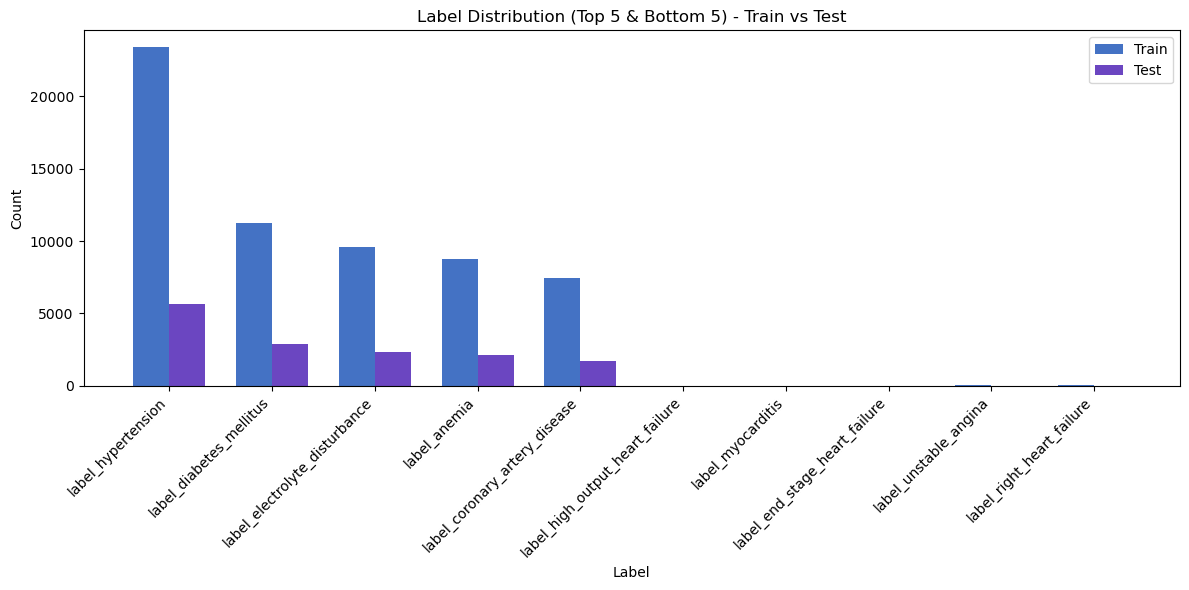

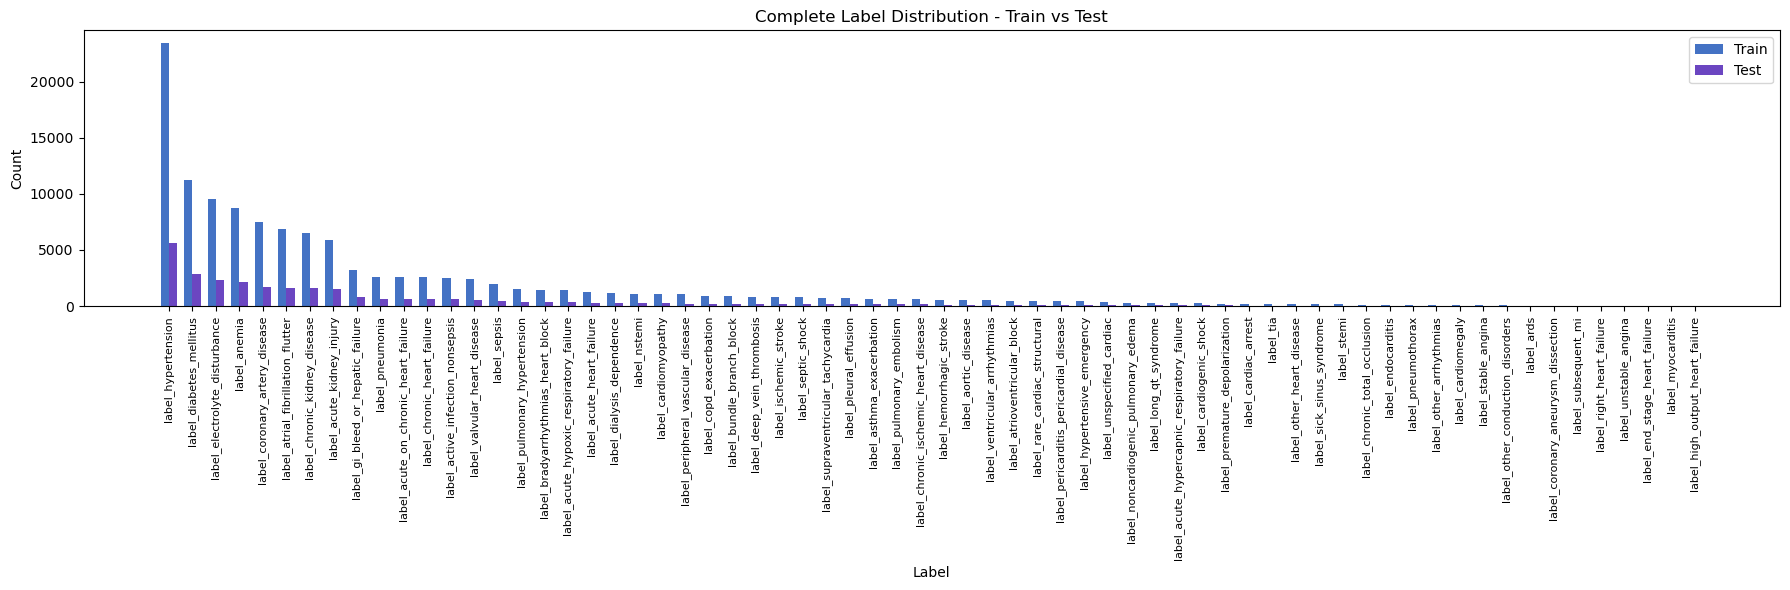


Train/Test split verification (first 5 labels):
label_hypertension: Train=80.5%, Test=19.5%
label_diabetes_mellitus: Train=79.6%, Test=20.4%
label_electrolyte_disturbance: Train=80.5%, Test=19.5%
label_anemia: Train=80.3%, Test=19.7%
label_coronary_artery_disease: Train=81.2%, Test=18.8%


In [304]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=closest_vitals['subject_id'])
)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

X_train_processed = pipeline.fit_transform(X_train)
X_test_processed = pipeline.transform(X_test)

# Align test columns with train (in case test is missing some categories)
X_test_processed = X_test_processed.reindex(columns=X_train_processed.columns, fill_value=0)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Number of targets: {y_train.shape[1]}")

# Calculate label counts for train and test
train_counts = y_train.sum().sort_values(ascending=False)
test_counts = y_test.sum().sort_values(ascending=False)

# Create DataFrame for plotting
label_df = pd.DataFrame({
    'label': train_counts.index,
    'train_count': train_counts.values,
    'test_count': test_counts.values
})

# Display top 10 labels
print("\nTop 10 labels:")
print(label_df.head(10))

# Get top 5 and bottom 5 labels by total count
label_df['total_count'] = label_df['train_count'] + label_df['test_count']
top_bottom_df = pd.concat([
    label_df.nlargest(5, 'total_count'),
    label_df.nsmallest(5, 'total_count')
])

# Plot top 5 and bottom 5 (train vs test)
plt.figure(figsize=(12, 6))
x = np.arange(len(top_bottom_df))
width = 0.35

plt.bar(x - width/2, top_bottom_df['train_count'], width, 
        label='Train', color='#4472C4')
plt.bar(x + width/2, top_bottom_df['test_count'], width, 
        label='Test', color='#6B46C1')

plt.xticks(x, top_bottom_df['label'], rotation=45, ha='right')
plt.title("Label Distribution (Top 5 & Bottom 5) - Train vs Test")
plt.ylabel("Count")
plt.xlabel("Label")
plt.legend()
plt.tight_layout()
plt.show()

# Plot all labels (train vs test)
plt.figure(figsize=(18, 6))
x = np.arange(len(label_df))
width = 0.35

plt.bar(x - width/2, label_df['train_count'], width, 
        label='Train', color='#4472C4')
plt.bar(x + width/2, label_df['test_count'], width, 
        label='Test', color='#6B46C1')

plt.xticks(x, label_df['label'], rotation=90, fontsize=8)
plt.title("Complete Label Distribution - Train vs Test")
plt.ylabel("Count")
plt.xlabel("Label")
plt.legend()
plt.tight_layout()
plt.show()

# Verify split ratios
print("\nTrain/Test split verification (first 5 labels):")
for label in label_df['label'][:5]:
    train_pct = label_df[label_df['label'] == label]['train_count'].values[0] / label_df[label_df['label'] == label]['total_count'].values[0] * 100
    test_pct = label_df[label_df['label'] == label]['test_count'].values[0] / label_df[label_df['label'] == label]['total_count'].values[0] * 100
    print(f"{label}: Train={train_pct:.1f}%, Test={test_pct:.1f}%")

In [305]:
from sklearn.multioutput import MultiOutputClassifier

# Train MultiOutputClassifier for all diagnoses
print("Training MultiOutputClassifier for diagnoses...")
print("This will train separate XGBoost models (one per label)")
print(f"{'='*70}\n")

multi_xgb = MultiOutputClassifier(
    XGBClassifier(
        max_depth=6,
        learning_rate=0.1,
        n_estimators=100,
        tree_method='hist',
        random_state=42,
        n_jobs=1
    ),
    n_jobs=-1
)

# Fit the model
multi_xgb.fit(X_train_processed, y_train)

print("\n✓ Training complete!")
print(f"Trained {len(multi_xgb.estimators_)} separate XGBoost models")

Training MultiOutputClassifier for diagnoses...
This will train separate XGBoost models (one per label)


✓ Training complete!
Trained 66 separate XGBoost models


In [308]:
print("Columns in y:")
print(y.columns.tolist())

Columns in y:
['label_active_infection_nonsepsis', 'label_acute_heart_failure', 'label_acute_hypercapnic_respiratory_failure', 'label_acute_hypoxic_respiratory_failure', 'label_acute_kidney_injury', 'label_acute_on_chronic_heart_failure', 'label_anemia', 'label_aortic_disease', 'label_ards', 'label_asthma_exacerbation', 'label_atrial_fibrillation_flutter', 'label_atrioventricular_block', 'label_bradyarrhythmias_heart_block', 'label_bundle_branch_block', 'label_cardiac_arrest', 'label_cardiogenic_shock', 'label_cardiomegaly', 'label_cardiomyopathy', 'label_chronic_heart_failure', 'label_chronic_ischemic_heart_disease', 'label_chronic_kidney_disease', 'label_chronic_total_occlusion', 'label_copd_exacerbation', 'label_coronary_aneurysm_dissection', 'label_coronary_artery_disease', 'label_deep_vein_thrombosis', 'label_diabetes_mellitus', 'label_dialysis_dependence', 'label_electrolyte_disturbance', 'label_end_stage_heart_failure', 'label_endocarditis', 'label_gi_bleed_or_hepatic_failure', 

In [309]:
# Evaluate performance for each of the labels
print(f"\n{'='*70}")
print(f"PERFORMANCE FOR ALL {len(y.columns)} DIAGNOSES")  # ← Changed
print(f"{'='*70}\n")

results = []

for i, target in enumerate(y.columns):  # ← Changed from machine_report_cols
    # Get predictions for this specific label
    y_pred_proba = multi_xgb.estimators_[i].predict_proba(X_test_processed)[:, 1]
    
    # Calculate metrics (only if both classes present in test set)
    n_pos_test = y_test[target].sum()
    n_test = len(y_test)
    
    if y_test[target].nunique() > 1:  # Both classes present
        auc = roc_auc_score(y_test[target], y_pred_proba)
        ap = average_precision_score(y_test[target], y_pred_proba)
    else:
        auc = np.nan
        ap = np.nan
    
    results.append({
        'target': target,
        'n_test_pos': int(n_pos_test),
        'pos_rate': y_test[target].mean(),
        'roc_auc': auc,
        'pr_auc': ap
    })
    
    # Print individual results
    print(f"{target}:")
    print(f"  Test positive: {int(n_pos_test)}/{n_test} ({y_test[target].mean():.4%})")
    if not np.isnan(auc):
        print(f"  ROC-AUC: {auc:.4f}")
        print(f"  PR-AUC:  {ap:.4f}")
    else:
        print(f"  Status: Single class in test set (cannot compute AUC)")
    print()

# Convert to DataFrame for analysis
results_df = pd.DataFrame(results)



PERFORMANCE FOR ALL 66 DIAGNOSES

label_active_infection_nonsepsis:
  Test positive: 592/24313 (2.4349%)
  ROC-AUC: 0.8964
  PR-AUC:  0.1215

label_acute_heart_failure:
  Test positive: 290/24313 (1.1928%)
  ROC-AUC: 0.8694
  PR-AUC:  0.0552

label_acute_hypercapnic_respiratory_failure:
  Test positive: 49/24313 (0.2015%)
  ROC-AUC: 0.9349
  PR-AUC:  0.0315

label_acute_hypoxic_respiratory_failure:
  Test positive: 365/24313 (1.5013%)
  ROC-AUC: 0.9380
  PR-AUC:  0.1763

label_acute_kidney_injury:
  Test positive: 1479/24313 (6.0832%)
  ROC-AUC: 0.9119
  PR-AUC:  0.3452

label_acute_on_chronic_heart_failure:
  Test positive: 650/24313 (2.6735%)
  ROC-AUC: 0.9462
  PR-AUC:  0.3334

label_anemia:
  Test positive: 2149/24313 (8.8389%)
  ROC-AUC: 0.9099
  PR-AUC:  0.4282

label_aortic_disease:
  Test positive: 120/24313 (0.4936%)
  ROC-AUC: 0.8822
  PR-AUC:  0.0292

label_ards:
  Test positive: 7/24313 (0.0288%)
  ROC-AUC: 0.8719
  PR-AUC:  0.0027

label_asthma_exacerbation:
  Test positi

In [310]:
# Summary statistics
print(f"\n{'='*70}")
print("SUMMARY STATISTICS")
print(f"{'='*70}")

valid_results = results_df[results_df['roc_auc'].notna()]

print(f"\nLabels with valid metrics: {len(valid_results)}/{len(results_df)}")
print(f"Mean ROC-AUC: {valid_results['roc_auc'].mean():.4f}")
print(f"Median ROC-AUC: {valid_results['roc_auc'].median():.4f}")
print(f"Mean PR-AUC: {valid_results['pr_auc'].mean():.4f}")
print(f"Median PR-AUC: {valid_results['pr_auc'].median():.4f}")

print(f"\nTop 10 Best Performing Labels (by ROC-AUC):")
print(valid_results.nlargest(10, 'roc_auc')[['target', 'n_test_pos', 'roc_auc', 'pr_auc']].to_string(index=False))

print(f"\nBottom 10 Worst Performing Labels (by ROC-AUC):")
print(valid_results.nsmallest(10, 'roc_auc')[['target', 'n_test_pos', 'roc_auc', 'pr_auc']].to_string(index=False))


SUMMARY STATISTICS

Labels with valid metrics: 66/66
Mean ROC-AUC: 0.8837
Median ROC-AUC: 0.8942
Mean PR-AUC: 0.1337
Median PR-AUC: 0.0751

Top 10 Best Performing Labels (by ROC-AUC):
                                 target  n_test_pos  roc_auc   pr_auc
              label_bundle_branch_block         202 0.964206 0.308454
           label_hypertensive_emergency          86 0.950240 0.181587
           label_atrioventricular_block         104 0.948629 0.234825
     label_bradyarrhythmias_heart_block         327 0.948113 0.275843
      label_atrial_fibrillation_flutter        1638 0.947454 0.683684
   label_acute_on_chronic_heart_failure         650 0.946221 0.333428
   label_chronic_ischemic_heart_disease         107 0.942671 0.109515
                label_cardiogenic_shock          69 0.942468 0.101698
                           label_sepsis         491 0.939939 0.270941
label_acute_hypoxic_respiratory_failure         365 0.937988 0.176339

Bottom 10 Worst Performing Labels (by ROC-AU

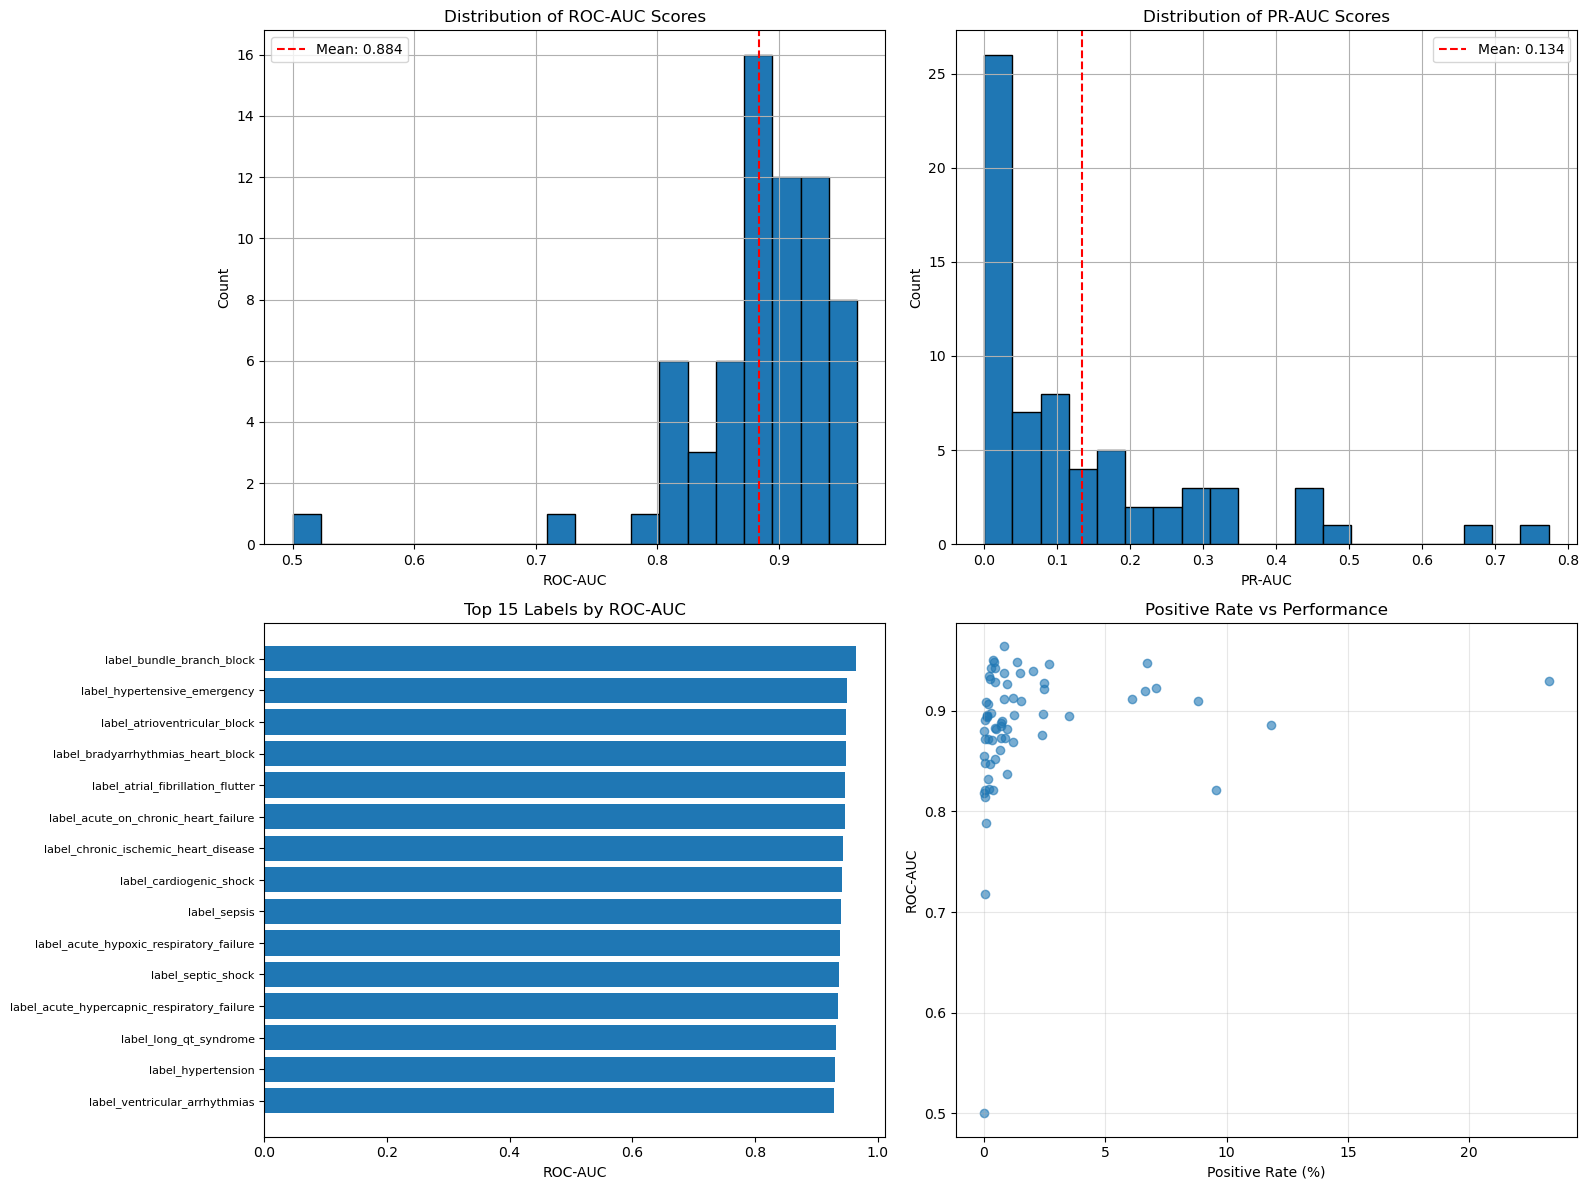

In [311]:
# Visualize performance across all labels
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. ROC-AUC distribution
valid_results['roc_auc'].hist(bins=20, ax=axes[0, 0], edgecolor='black')
axes[0, 0].set_xlabel('ROC-AUC')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of ROC-AUC Scores')
axes[0, 0].axvline(valid_results['roc_auc'].mean(), color='red', linestyle='--', label=f"Mean: {valid_results['roc_auc'].mean():.3f}")
axes[0, 0].legend()

# 2. PR-AUC distribution
valid_results['pr_auc'].hist(bins=20, ax=axes[0, 1], edgecolor='black')
axes[0, 1].set_xlabel('PR-AUC')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Distribution of PR-AUC Scores')
axes[0, 1].axvline(valid_results['pr_auc'].mean(), color='red', linestyle='--', label=f"Mean: {valid_results['pr_auc'].mean():.3f}")
axes[0, 1].legend()

# 3. Top 15 labels by ROC-AUC
top_15 = valid_results.nlargest(15, 'roc_auc')
axes[1, 0].barh(range(len(top_15)), top_15['roc_auc'])
axes[1, 0].set_yticks(range(len(top_15)))
axes[1, 0].set_yticklabels(top_15['target'], fontsize=8)
axes[1, 0].set_xlabel('ROC-AUC')
axes[1, 0].set_title('Top 15 Labels by ROC-AUC')
axes[1, 0].invert_yaxis()

# 4. Positive rate vs ROC-AUC
axes[1, 1].scatter(valid_results['pos_rate']*100, valid_results['roc_auc'], alpha=0.6)
axes[1, 1].set_xlabel('Positive Rate (%)')
axes[1, 1].set_ylabel('ROC-AUC')
axes[1, 1].set_title('Positive Rate vs Performance')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Visualizing: ['label_bundle_branch_block', 'label_chronic_total_occlusion', 'label_high_output_heart_failure']


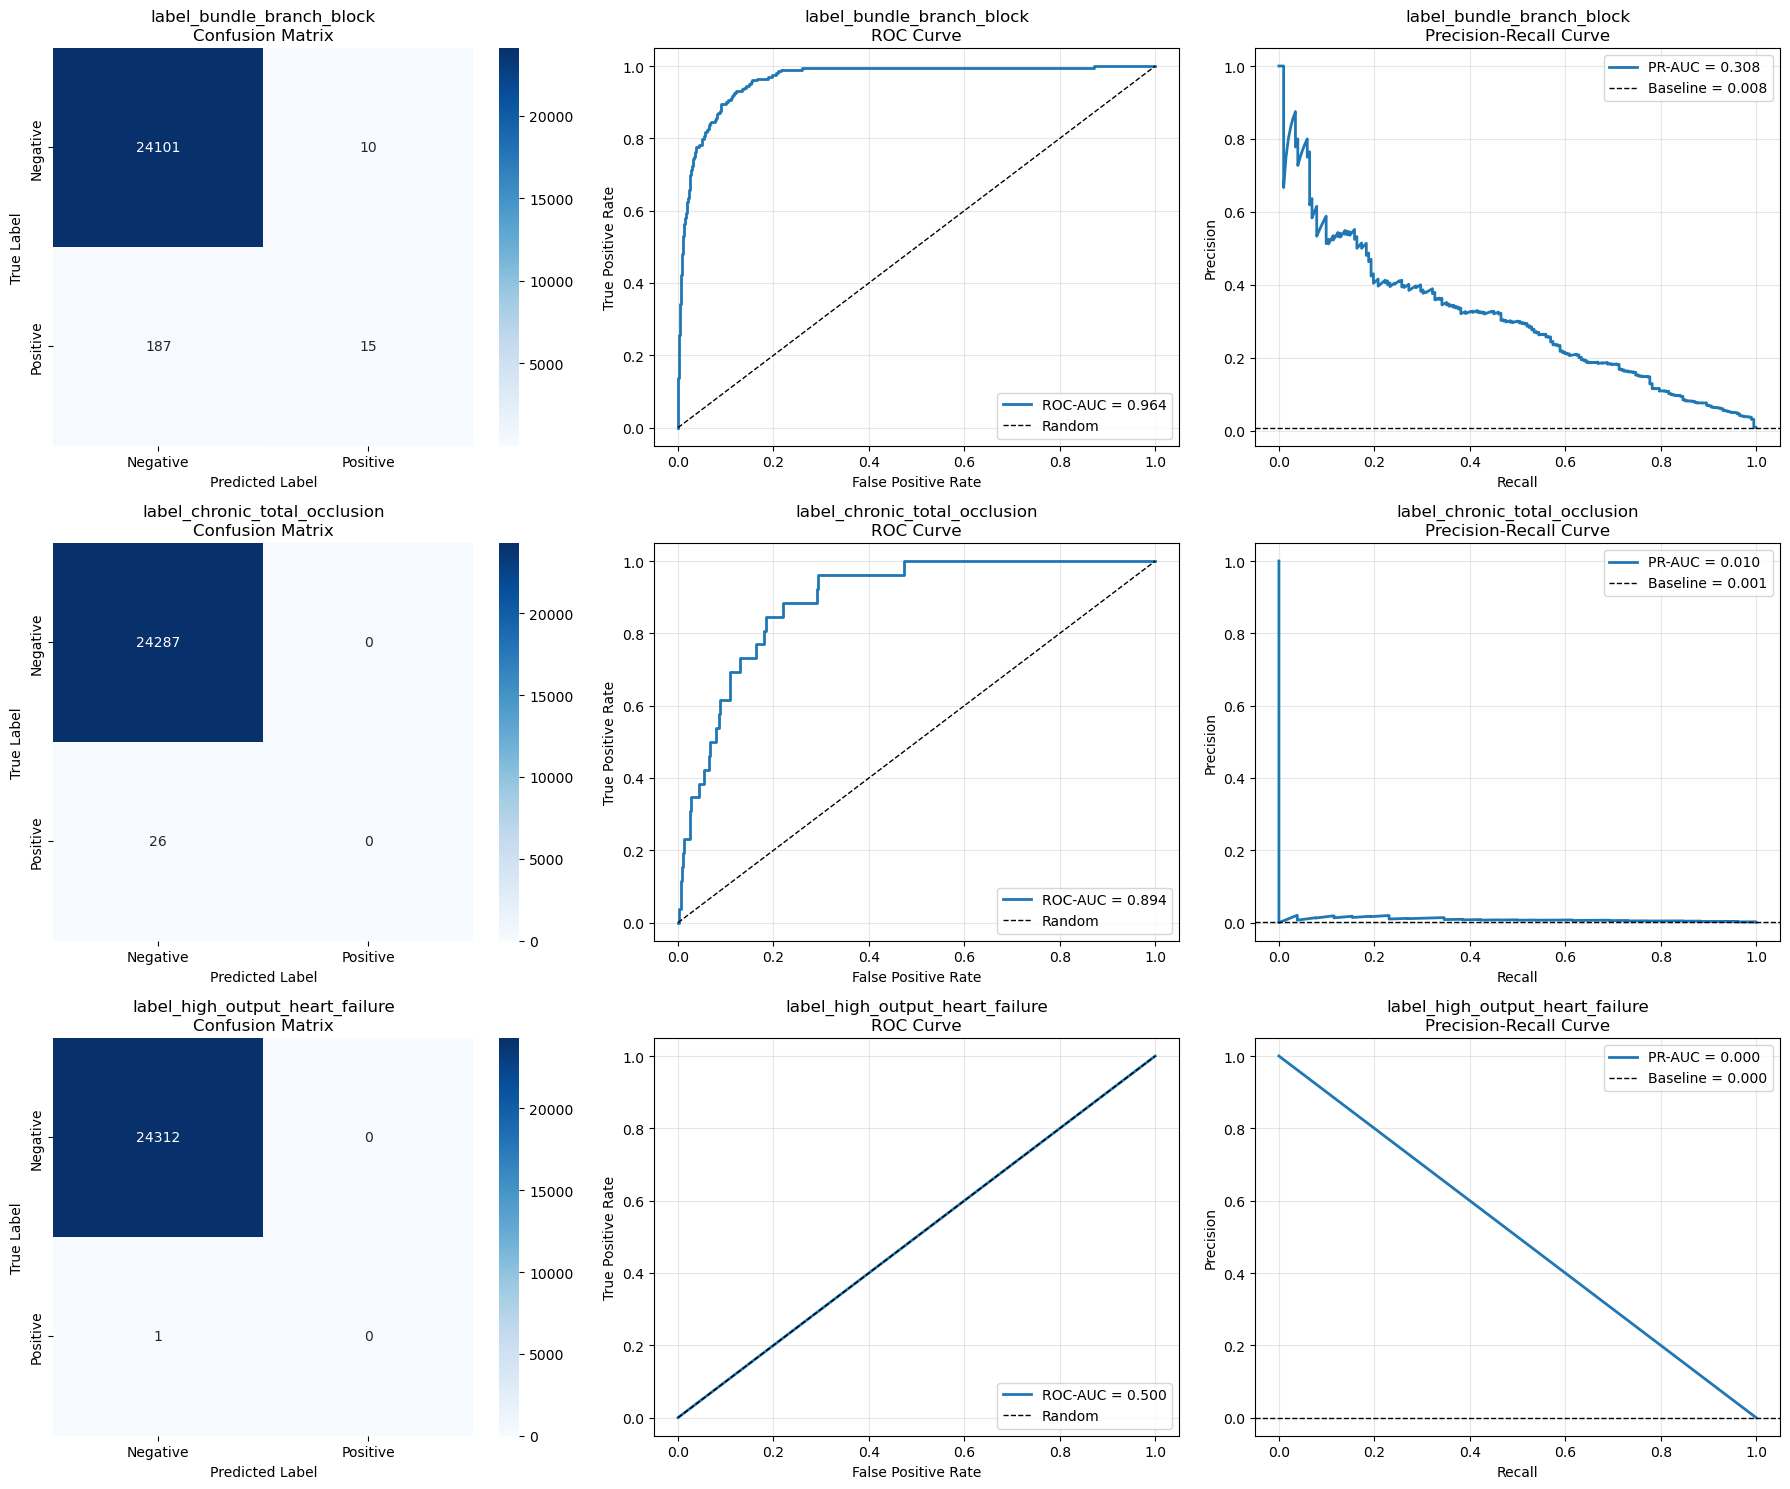


Visualized labels:
  Best:   label_bundle_branch_block (ROC-AUC: 0.964)
  Medium: label_chronic_total_occlusion (ROC-AUC: 0.894)
  Worst:  label_high_output_heart_failure (ROC-AUC: 0.500)


In [312]:
# Select a few representative labels to visualize
# Choose: best performer, worst performer, and a medium performer
valid_results_sorted = results_df[results_df['roc_auc'].notna()].sort_values('roc_auc', ascending=False)

best_label = valid_results_sorted.iloc[0]['target']
worst_label = valid_results_sorted.iloc[-1]['target']
medium_label = valid_results_sorted.iloc[len(valid_results_sorted)//2]['target']

selected_labels = [best_label, medium_label, worst_label]
print(f"Visualizing: {selected_labels}")

# Use y.columns instead of machine_report_cols
label_cols_list = y.columns.tolist()

# Create figure with 3 rows, 3 columns
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for row, label in enumerate(selected_labels):
    # Get index for this label
    label_idx = label_cols_list.index(label)
    
    # Get predictions for this label - use column name directly
    y_true = y_test[label]  # ← Changed back to use column name
    y_pred = multi_xgb.estimators_[label_idx].predict(X_test_processed)
    y_pred_proba = multi_xgb.estimators_[label_idx].predict_proba(X_test_processed)[:, 1]
    
    # Get metrics
    label_metrics = results_df[results_df['target'] == label].iloc[0]
    roc_auc = label_metrics['roc_auc']
    pr_auc = label_metrics['pr_auc']
    
    # Column 1: Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, 0],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[row, 0].set_title(f'{label}\nConfusion Matrix')
    axes[row, 0].set_ylabel('True Label')
    axes[row, 0].set_xlabel('Predicted Label')
    
    # Column 2: ROC Curve
    if y_true.nunique() > 1:  # Only plot if both classes present
        fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
        axes[row, 1].plot(fpr, tpr, linewidth=2, label=f'ROC-AUC = {roc_auc:.3f}')
        axes[row, 1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
        axes[row, 1].set_xlabel('False Positive Rate')
        axes[row, 1].set_ylabel('True Positive Rate')
        axes[row, 1].set_title(f'{label}\nROC Curve')
        axes[row, 1].legend(loc='lower right')
        axes[row, 1].grid(True, alpha=0.3)
    else:
        axes[row, 1].text(0.5, 0.5, 'Single class\nin test set', 
                         ha='center', va='center', fontsize=12)
        axes[row, 1].set_title(f'{label}\nROC Curve (N/A)')
    
    # Column 3: Precision-Recall Curve
    if y_true.nunique() > 1:  # Only plot if both classes present
        precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
        baseline_precision = y_true.mean()
        axes[row, 2].plot(recall, precision, linewidth=2, label=f'PR-AUC = {pr_auc:.3f}')
        axes[row, 2].axhline(baseline_precision, color='k', linestyle='--', 
                            linewidth=1, label=f'Baseline = {baseline_precision:.3f}')
        axes[row, 2].set_xlabel('Recall')
        axes[row, 2].set_ylabel('Precision')
        axes[row, 2].set_title(f'{label}\nPrecision-Recall Curve')
        axes[row, 2].legend(loc='best')
        axes[row, 2].grid(True, alpha=0.3)
    else:
        axes[row, 2].text(0.5, 0.5, 'Single class\nin test set', 
                         ha='center', va='center', fontsize=12)
        axes[row, 2].set_title(f'{label}\nPR Curve (N/A)')

plt.tight_layout()
plt.show()

print(f"\nVisualized labels:")
print(f"  Best:   {best_label} (ROC-AUC: {valid_results_sorted.iloc[0]['roc_auc']:.3f})")
print(f"  Medium: {medium_label} (ROC-AUC: {valid_results_sorted.iloc[len(valid_results_sorted)//2]['roc_auc']:.3f})")
print(f"  Worst:  {worst_label} (ROC-AUC: {valid_results_sorted.iloc[-1]['roc_auc']:.3f})")

Plotting 66 labels with valid metrics


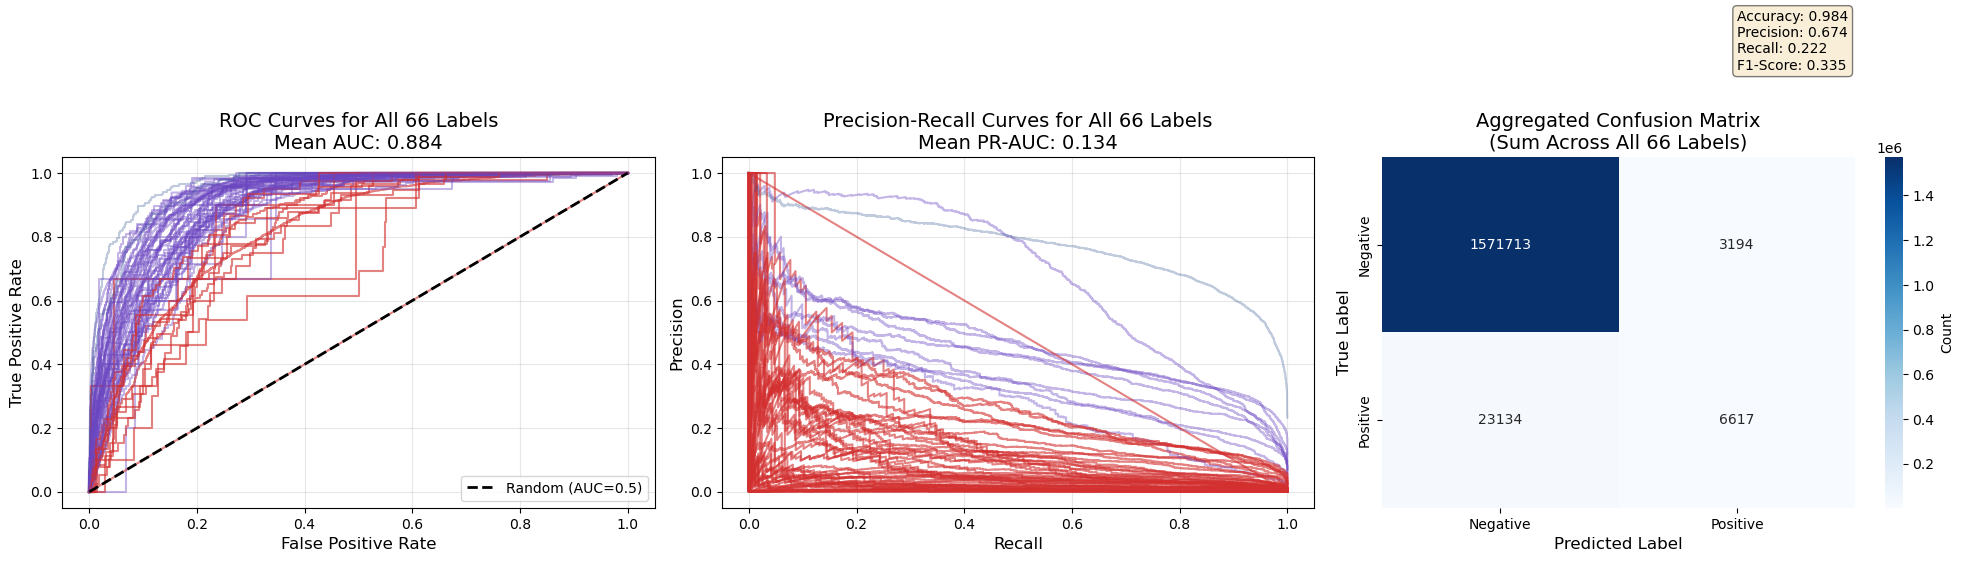


Aggregated Metrics (across all 66 labels):
  Total Predictions: 1604658
  True Negatives:  1571713 (97.9%)
  False Positives: 3194 (0.2%)
  False Negatives: 23134 (1.4%)
  True Positives:  6617 (0.4%)
  Overall Accuracy: 0.984
  Overall Precision: 0.674
  Overall Recall: 0.222
  Overall F1-Score: 0.335


In [313]:
# Get all valid labels (those with both classes in test set)
valid_labels = []
for label in y.columns:  # ← Changed from machine_report_cols
    if y_test[label].nunique() > 1:  # ← Changed to use column name
        valid_labels.append(label)

print(f"Plotting {len(valid_labels)} labels with valid metrics")

# Create figure with 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: All ROC Curves ---
for label in valid_labels:
    label_idx = list(y.columns).index(label)  # ← Changed
    y_true = y_test[label]  # ← Changed to use column name
    y_pred_proba = multi_xgb.estimators_[label_idx].predict_proba(X_test_processed)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    label_metrics = results_df[results_df['target'] == label].iloc[0]
    roc_auc = label_metrics['roc_auc']
    
    # Use different colors for different performance levels
    if roc_auc >= 0.95:
        color = '#2E5090'  # Dark blue for excellent
        alpha = 0.3
    elif roc_auc >= 0.85:
        color = '#6B46C1'  # Purple for good
        alpha = 0.4
    else:
        color = '#D32F2F'  # Red for poor
        alpha = 0.6
    
    axes[0].plot(fpr, tpr, linewidth=1.5, alpha=alpha, color=color)

# Add random baseline and formatting
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title(f'ROC Curves for All {len(valid_labels)} Labels\nMean AUC: {results_df["roc_auc"].mean():.3f}', fontsize=14)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Plot 2: All Precision-Recall Curves ---
for label in valid_labels:
    label_idx = list(y.columns).index(label)  # ← Changed
    y_true = y_test[label]  # ← Changed to use column name
    y_pred_proba = multi_xgb.estimators_[label_idx].predict_proba(X_test_processed)[:, 1]
    
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    label_metrics = results_df[results_df['target'] == label].iloc[0]
    pr_auc = label_metrics['pr_auc']
    
    # Use different colors for different performance levels
    if pr_auc >= 0.7:
        color = '#2E5090'  # Dark blue for excellent
        alpha = 0.3
    elif pr_auc >= 0.3:
        color = '#6B46C1'  # Purple for moderate
        alpha = 0.4
    else:
        color = '#D32F2F'  # Red for poor
        alpha = 0.6
    
    axes[1].plot(recall, precision, linewidth=1.5, alpha=alpha, color=color)

axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title(f'Precision-Recall Curves for All {len(valid_labels)} Labels\nMean PR-AUC: {results_df["pr_auc"].mean():.3f}', fontsize=14)
axes[1].grid(True, alpha=0.3)

# --- Plot 3: Aggregated Confusion Matrix (sum of all) ---
# Sum all confusion matrices
total_cm = np.zeros((2, 2))
for label in valid_labels:
    label_idx = list(y.columns).index(label)  # ← Changed
    y_true = y_test[label]  # ← Changed to use column name
    y_pred = multi_xgb.estimators_[label_idx].predict(X_test_processed)
    cm = confusion_matrix(y_true, y_pred)
    total_cm += cm

# Plot aggregated confusion matrix
sns.heatmap(total_cm, annot=True, fmt='.0f', cmap='Blues', ax=axes[2],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
axes[2].set_title(f'Aggregated Confusion Matrix\n(Sum Across All {len(valid_labels)} Labels)', fontsize=14)
axes[2].set_ylabel('True Label', fontsize=12)
axes[2].set_xlabel('Predicted Label', fontsize=12)

# Calculate overall metrics from aggregated CM
tn, fp, fn, tp = total_cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# Add text with overall metrics
metrics_text = f'Accuracy: {accuracy:.3f}\nPrecision: {precision:.3f}\nRecall: {recall:.3f}\nF1-Score: {f1:.3f}'
axes[2].text(1.5, -0.5, metrics_text, fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nAggregated Metrics (across all {len(valid_labels)} labels):")
print(f"  Total Predictions: {int(total_cm.sum())}")
print(f"  True Negatives:  {int(tn)} ({tn/total_cm.sum()*100:.1f}%)")
print(f"  False Positives: {int(fp)} ({fp/total_cm.sum()*100:.1f}%)")
print(f"  False Negatives: {int(fn)} ({fn/total_cm.sum()*100:.1f}%)")
print(f"  True Positives:  {int(tp)} ({tp/total_cm.sum()*100:.1f}%)")
print(f"  Overall Accuracy: {accuracy:.3f}")
print(f"  Overall Precision: {precision:.3f}")
print(f"  Overall Recall: {recall:.3f}")
print(f"  Overall F1-Score: {f1:.3f}")

In [ ]:
# Save results to CSV for later analysis
results_df.to_csv('xgboost_baseline_diagnosis_results.csv', index=False)
print("Results saved to 'xgboost_baseline_diagnosis_results.csv'")

results_df_sorted = results_df.sort_values('pr_auc', ascending=False)
# Display full results DataFrame
print("\nFull Results:")
print(results_df_sorted.to_string(index=False))

Results saved to 'xgboost_baseline_diagnosis_results.csv'

Full Results:
                           target  n_test_pos  pos_rate  roc_auc   pr_auc
                             pvcs        5656  0.232633 0.930068 0.773194
         left_bundle_branch_block        1638  0.067371 0.947454 0.683684
                     st_elevation        2879  0.118414 0.885501 0.467628
                 st_t_abnormality        1724  0.070909 0.922422 0.463279
         right_atrial_enlargement        1616  0.066466 0.919192 0.428962
          ventricular_tachycardia        2149  0.088389 0.909922 0.428213
                   atrial_flutter        1479  0.060832 0.911872 0.345247
     supraventricular_tachycardia         650  0.026735 0.946221 0.333428
                 t_wave_inversion        2322  0.095504 0.821084 0.322660
  left_posterior_fascicular_block         202  0.008308 0.964206 0.308454
   left_anterior_fascicular_block         327  0.013450 0.948113 0.275843
                     pericarditis      

The XGBoost baseline achieved strong overall discrimination across 21 machine-generated ECG report labels, with mean ROC-AUC (measuring how well the model ranks positive cases higher than negative cases across all thresholds) of 0.933 and mean PR-AUC (measuring how well the model finds positive cases without creating excessive false alarms, particularly important for imbalanced data) of 0.485. Common rhythm classifications showed excellent performance.However, rare conditions demonstrated the expected imbalanced-data challenge, showing substantially lower precision-recall performance despite moderate ROC-AUC scores (0.84-0.89), indicating that static ECG features alone struggle to identify these infrequent patterns. Overall impression labels (normal, borderline, abnormal ECG) achieved strong balanced performance (ROC-AUC: 0.92-0.97, PR-AUC: 0.61-0.91), validating that aggregate ECG measurements effectively capture overall cardiac abnormality and establishing a solid baseline (mean ROC-AUC: 0.933) for comparison with temporal deep learning models.